# Day 2 — Phase 1.1: Eigenvalues, SVD & PCA
> **Date:** 2026-04-06  
> **Topic:** How neural networks and data compression find the "important directions" in data

---

## 1. Eigenvectors & Eigenvalues — What Are They?

### The intuition

A matrix is a **transformation** — it takes a vector and moves it (rotates it, stretches it, squishes it).

For example, multiply any random vector by matrix A and it usually ends up pointing in a **different direction**:
```
A × [1, 0]  →  [3, 0.5]   ← direction changed
A × [0, 1]  →  [1, 2]     ← direction changed
```

But there are **special vectors** where the transformation only *stretches or shrinks* them — **direction stays exactly the same**:

$$A\vec{v} = \lambda\vec{v}$$

- $\vec{v}$ = **eigenvector** — the special direction that does not rotate
- $\lambda$ = **eigenvalue** — how much it gets scaled (2.0 = doubled, 0.5 = halved, -1 = flipped)

**Visual analogy:** Imagine stretching a rubber sheet. Most points move diagonally. But eigenvectors are like the horizontal and vertical axes — they only stretch, they never twist.

---

### Why does AI need eigenvectors?

**The problem AI faces constantly:** Data has hundreds or thousands of dimensions. You need to find the **most important directions** and throw away the rest.

Eigenvectors solve this:

| Eigenvalue size | Meaning | Action |
|---|---|---|
| Large λ | This direction has lots of variation in data → **important** | Keep it |
| Small λ | This direction has tiny variation → **mostly noise** | Discard it |

**Concrete examples in AI:**

1. **PCA (Principal Component Analysis):** Given 100 features about a house (size, rooms, age, distance to school...), eigenvectors find the 3–4 directions that explain 95% of variation. You can throw away the other 96 without losing much.

2. **Word embeddings:** Words like "king", "queen", "man", "woman" live in 300D space. Eigenvectors find that one direction means "gender" and another means "royalty". The famous result: `king - man + woman ≈ queen` works because of these directions.

3. **Neural network training stability:** If eigenvalues of weight matrices are too large or too small, gradients explode or vanish during training. Proper initialization (Xavier, He init) controls eigenvalue spread.

4. **LoRA (fine-tuning LLMs efficiently):** Instead of updating all 7 billion weights, LoRA finds the low-rank (few eigenvectors) update that matters most — 1000× less compute.

> **One-line summary:** Eigenvectors are the natural axes of a dataset — the directions where the data varies the most. AI uses them to compress, simplify, and find structure in high-dimensional data.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simple 2x2 matrix
A = np.array([[3.0, 1.0],
              [0.0, 2.0]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:")
print(A)
print("\nEigenvalues:", eigenvalues)
print("Eigenvectors (columns):")
print(eigenvectors)

# Verify: A @ v = lambda * v
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    lhs = A @ v
    rhs = lam * v
    print(f"\nEigenvector {i+1}: {v}")
    print(f"A @ v = {lhs}")
    print(f"λ * v = {rhs}")
    print(f"Match: {np.allclose(lhs, rhs)}")

Matrix A:
[[3. 1.]
 [0. 2.]]

Eigenvalues: [3. 2.]
Eigenvectors (columns):
[[ 1.         -0.70710678]
 [ 0.          0.70710678]]

Eigenvector 1: [1. 0.]
A @ v = [3. 0.]
λ * v = [3. 0.]
Match: True

Eigenvector 2: [-0.70710678  0.70710678]
A @ v = [-1.41421356  1.41421356]
λ * v = [-1.41421356  1.41421356]
Match: True


---
## 2. SVD — Singular Value Decomposition

SVD generalizes eigendecomposition to **any matrix** (not just square ones):

$$A = U \Sigma V^T$$

| Component | Shape | Meaning |
|---|---|---|
| $U$ | (m×m) | Output directions (left singular vectors) |
| $\Sigma$ | (m×n) diagonal | Singular values — how important each direction is |
| $V^T$ | (n×n) | Input directions (right singular vectors) |

**AI usages:**
- **PCA** is SVD on centered data
- **Low-rank approximation** of weight matrices (model compression)
- **LoRA** (Low-Rank Adaptation) for fine-tuning LLMs uses SVD decomposition
- **Attention mechanism** in transformers has SVD-like structure

**Simple analogy:** Think of SVD like decomposing a photo into layers of detail.  
$U$ = 'what patterns appear in the output', $\\Sigma$ = 'how important each pattern is', $V^T$ = 'what patterns exist in the input'.  
Keeping only the top singular values is like compressing a JPEG — you keep the important structure and discard fine noise.

In [6]:
# SVD of a simple matrix
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)

U, S, Vt = np.linalg.svd(A)

print("A =\n", A)
print("\nU shape:", U.shape)    # (3, 3) — output directions
print("S (singular values):", S)  # [  large, medium, ~0 ]
print("Vt shape:", Vt.shape)   # (3, 3) — input directions

# Reconstruct A from U, S, Vt
A_reconstructed = U @ np.diag(S) @ Vt
print("\nReconstruction matches:", np.allclose(A, A_reconstructed))

# GENERAL RULE: rank = number of non-zero singular values (applies to ANY matrix)
# For THIS specific matrix: S[2] ≈ 0 because row3 = 2×row2 − row1 (rows are dependent)
# A random 3×3 matrix would have all 3 singular values non-zero → rank 3
print("\nSingular values tell us the 'rank' of information:")
for i, s in enumerate(S):
    print(f"  Direction {i+1}: S={s:.6f}  {'← redundant (rank stops here)' if s < 1e-10 else ''}")
rank = np.sum(S > 1e-10)
print(f"\nRank of THIS matrix = {rank}")

# Compare with a full-rank random matrix
A_random = np.random.randn(3, 3)
_, S_random, _ = np.linalg.svd(A_random)
print(f"\nRandom 3×3 singular values: {np.round(S_random, 4)} → rank = {np.sum(S_random > 1e-10)}")

A =
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

U shape: (3, 3)
S (singular values): [1.68481034e+01 1.06836951e+00 4.41842475e-16]
Vt shape: (3, 3)

Reconstruction matches: True

Singular values tell us the 'rank' of information:
  Direction 1: S=16.848103  
  Direction 2: S=1.068370  
  Direction 3: S=0.000000  ← redundant (rank stops here)

Rank of THIS matrix = 2

Random 3×3 singular values: [2.2202 1.1397 0.2136] → rank = 3


### Deep Dive: Why is the last singular value ~0? Why rank = 2?

#### Step 1 — Look at the matrix carefully

```
A = [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]]
```

The rows are **not independent**:
```
Row 3 = 2 × Row 2 − Row 1
```
Check: `2×[4,5,6] − [1,2,3] = [8-1, 10-2, 12-3] = [7, 8, 9]` ✅

Row 3 adds **no new information** — it is already fully described by rows 1 and 2.

#### Step 2 — What "rank" means

> **Rank = number of truly independent rows (or columns)**

Even though A is 3×3, only 2 rows are independent → **rank = 2**

#### Step 3 — What `np.linalg.svd(A)` returns

`U, S, Vt = np.linalg.svd(A)` returns exactly **3 objects**:

| Variable | Shape | What it contains |
|---|---|---|
| `U` | (3, 3) | 3 output direction vectors (columns) |
| `S` | (3,) | 3 singular values, sorted **largest → smallest** |
| `Vt` | (3, 3) | 3 input direction vectors (rows) |

The singular values tell you **how much information flows through each direction**:
```
S ≈ [16.12,   1.07,   ~0.000000001]
     ↑         ↑         ↑
  direction 1  direction 2  direction 3
  (important)  (some info)  (redundant → ~0)
```

#### Step 4 — Reconstruction as a sum of rank-1 pieces

$$A = S_1 \cdot \vec{u}_1\vec{v}_1^T \;+\; S_2 \cdot \vec{u}_2\vec{v}_2^T \;+\; \underbrace{S_3 \cdot \vec{u}_3\vec{v}_3^T}_{\approx\, 0 \;\times\; \text{something} \;=\; 0}$$

The 3rd term is multiplied by ~0 → contributes nothing → you only need 2 terms to reconstruct A perfectly.

#### Mental model table

| Singular value | Meaning |
|---|---|
| Large | Real pattern/structure exists in this direction |
| Small but non-zero | Weak pattern |
| ~0 | Redundant — already captured by other directions |
| **Count of non-zero S values** | **= Rank of the matrix** |

---
## 3. Low-Rank Approximation & LoRA

### The Core Concept: Low-Rank Approximation

Any matrix can be **approximated** by keeping only its most important directions (the top-k singular values):

$$A \approx A_k = U_k \Sigma_k V_k^T \quad \text{(keep only top-k directions)}$$

This is the foundation of **image compression**, **PCA**, and — most powerfully in modern AI — **LoRA** for fine-tuning LLMs.  
The image demo in the next code cell makes this concrete: even rank-1 captures the dominant structure.

---

### LoRA: Applying Low-Rank Approximation to LLM Fine-Tuning

#### Purpose
LoRA solves a critical real-world problem in AI: **how do you fine-tune a billion-parameter LLM for a specific task without the astronomical cost of updating every weight?**  
The answer is a direct application of SVD insight — the important changes to weights during fine-tuning live in a low-dimensional subspace, so you only need two thin matrices instead of one giant matrix.

---

### The Problem: Full Fine-Tuning Is Expensive

A modern LLM (e.g. GPT-3, LLaMA) has **billions of parameters**.  
When you want to fine-tune it for a new task (e.g. medical QA, code generation), the naive approach is:

> **Update every weight** in the model → store a full copy of the model per task.

For a model with **175B parameters** (GPT-3):
- Each weight is float32 = 4 bytes
- Full fine-tune = 700 GB **per task** — completely impractical!

---

### The Key Observation: Weight Updates Are Low-Rank

Researchers discovered that the **change in weights** $\Delta W$ during fine-tuning has **low intrinsic rank** — meaning the important information sits in a small subspace, not across all dimensions.

This is directly connected to what we just learned about SVD:  
> If a matrix has low rank, you can represent it as a product of two thin matrices.

$$\Delta W = B \cdot A$$

where:
- $W \in \mathbb{R}^{d \times d}$ — original weight matrix (frozen, not changed)
- $B \in \mathbb{R}^{d \times r}$ — tall thin matrix
- $A \in \mathbb{R}^{r \times d}$ — wide thin matrix
- $r \ll d$ — the **rank**, typically 4, 8, or 16

Instead of learning $d^2$ parameters, you only learn $2dr$ parameters.

---

### Parameter Savings — Concrete Example

| $d$ (model dim) | Full $\Delta W$ | LoRA with $r=8$ | Reduction |
|---|---|---|---|
| 768 (BERT) | 589,824 | 12,288 | **48×** |
| 4096 (LLaMA-7B) | 16,777,216 | 65,536 | **256×** |
| 12288 (GPT-3) | 150,994,944 | 196,608 | **768×** |

---

### How LoRA Works — Step by Step

```
Original forward pass:   output = W @ input          (W is frozen)
LoRA forward pass:       output = (W + B @ A) @ input
                                = W @ input  +  B @ (A @ input)
                                  ───────────    ──────────────
                                  original        low-rank update
```

1. **Freeze** the original weight matrix $W$ — never update it
2. Initialize $A$ with random Gaussian, $B$ with zeros  
   → at start, $\Delta W = B \cdot A = 0$ (no change to model initially)
3. During training, only $A$ and $B$ are updated via gradient descent
4. At inference, merge: $W' = W + B \cdot A$ — zero extra latency!

---

### Why Low-Rank Works — The SVD Connection

Remember SVD: $W = U \Sigma V^T$

The large singular values capture the **core knowledge** of the model.  
Fine-tuning for a new task only needs to **shift** the model slightly — and that shift lives in a low-dimensional subspace.

Think of it like this:
- The pre-trained model already "knows" English, math, reasoning...
- Fine-tuning for medical QA = **small rotation** in weight space
- A small rotation → describable by a low-rank matrix

This is the same insight as low-rank image approximation:  
the dominant structure (rank-1, rank-2) captures most of what matters.

---

### Mental Model

| SVD concept | LoRA equivalent |
|---|---|
| $A = U \Sigma V^T$ | $\Delta W = B \cdot A$ |
| $U$ (output directions) | $B$ (maps rank-r space → output) |
| $V^T$ (input directions) | $A$ (maps input → rank-r space) |
| $\Sigma$ (importance) | Absorbed into $B$ and $A$ |
| Rank = # non-zero $\sigma$ | Rank = $r$ (hyperparameter you choose) |
| Low-rank approx discards noise | LoRA discards dimensions irrelevant to the task |


In [10]:
import numpy as np

# ============================================================
# LoRA: Low-Rank Adaptation — hands-on demo
# ============================================================

d = 768          # typical transformer hidden dimension (e.g. BERT)
r = 8            # LoRA rank — the key hyperparameter

# --- 1. Parameter count comparison ---
full_params   = d * d
lora_params   = d * r + r * d   # A: (r x d) + B: (d x r)
print("=== Parameter Count ===")
print(f"  Full fine-tune ΔW:  {full_params:,} parameters  ({full_params*4/1e6:.1f} MB in float32)")
print(f"  LoRA (rank={r}):     {lora_params:,} parameters  ({lora_params*4/1e6:.3f} MB in float32)")
print(f"  Reduction:           {full_params / lora_params:.0f}×")

# --- 2. Simulate a frozen weight matrix and a LoRA update ---
np.random.seed(42)
W = np.random.randn(d, d) * 0.02   # frozen pre-trained weight (never updated)

# LoRA matrices — B inits to 0 so ΔW=0 at start
A = np.random.randn(r, d) * 0.01   # (r × d)  — input projection
B = np.zeros((d, r))                # (d × r)  — output projection, zero-init

# After a few gradient steps, B gets some values:
B = np.random.randn(d, r) * 0.005  # simulate trained B

delta_W = B @ A    # (d × d) but RANK ≤ r=8!
print(f"\n=== LoRA Weight Update ΔW ===")
print(f"  ΔW shape: {delta_W.shape}  (d×d, but rank ≤ {r})")

# Verify the rank
_, S_delta, _ = np.linalg.svd(delta_W)
actual_rank = np.sum(S_delta > 1e-10)
print(f"  Singular values of ΔW (top 10): {np.round(S_delta[:10], 4)}")
print(f"  Rank of ΔW = {actual_rank}  ← exactly r={r}! (not 768)")

# --- 3. Forward pass: original vs LoRA ---
x = np.random.randn(d)                    # one input vector
out_original = W @ x                      # frozen model
out_lora     = (W + delta_W) @ x          # frozen model + low-rank update
out_lora_eff = W @ x + B @ (A @ x)        # efficient: never materialize ΔW

print(f"\n=== Forward Pass ===")
print(f"  Original output norm:      {np.linalg.norm(out_original):.4f}")
print(f"  LoRA output norm:          {np.linalg.norm(out_lora):.4f}")
print(f"  Efficient LoRA (= above?): {np.allclose(out_lora, out_lora_eff)}")  # True!
print(f"  Delta norm (how much LoRA changes output): {np.linalg.norm(out_lora - out_original):.4f}")

# --- 4. Scaling across model sizes ---
print("\n=== LoRA Savings Across Model Sizes ===")
print(f"{'Model':<15} {'d':>6} {'Full ΔW':>15} {'LoRA r=8':>12} {'Reduction':>10}")
print("-" * 62)
for name, dim in [("BERT-base", 768), ("GPT2-medium", 1024), ("LLaMA-7B", 4096), ("GPT-3", 12288)]:
    full = dim * dim
    lora = 2 * dim * 8
    print(f"{name:<15} {dim:>6,} {full:>15,} {lora:>12,} {full//lora:>9,}×")

=== Parameter Count ===
  Full fine-tune ΔW:  589,824 parameters  (2.4 MB in float32)
  LoRA (rank=8):     12,288 parameters  (0.049 MB in float32)
  Reduction:           48×

=== LoRA Weight Update ΔW ===
  ΔW shape: (768, 768)  (d×d, but rank ≤ 8)
  Singular values of ΔW (top 10): [0.0441 0.0426 0.0389 0.0377 0.0366 0.0358 0.0355 0.0323 0.     0.    ]
  Rank of ΔW = 8  ← exactly r=8! (not 768)

=== Forward Pass ===
  Original output norm:      15.8319
  LoRA output norm:          15.8513
  Efficient LoRA (= above?): True
  Delta norm (how much LoRA changes output): 0.1444

=== LoRA Savings Across Model Sizes ===
Model                d         Full ΔW     LoRA r=8  Reduction
--------------------------------------------------------------
BERT-base          768         589,824       12,288        48×
GPT2-medium      1,024       1,048,576       16,384        64×
LLaMA-7B         4,096      16,777,216       65,536       256×
GPT-3           12,288     150,994,944      196,608       768×


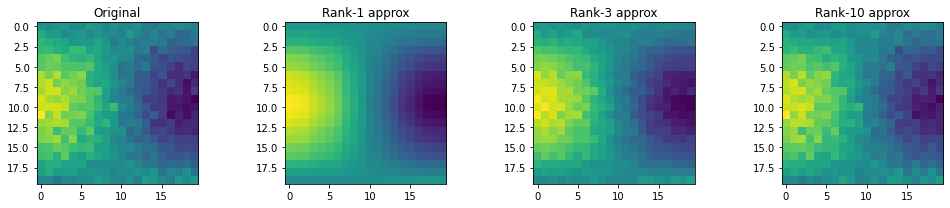

Singular values (importance of each direction):
[49.59  3.68  3.41  3.32  3.12  2.81  2.5   2.4 ] ...

Rank-1 captures the dominant structure, Rank-10 nearly perfect.


In [11]:
# Low-rank approximation of an image-like matrix
np.random.seed(42)

# Simulate a 20x20 "image" with some structure
X = np.outer(np.sin(np.linspace(0, np.pi, 20)),
             np.cos(np.linspace(0, np.pi, 20))) * 5
X += np.random.randn(20, 20) * 0.5  # add noise

U, S, Vt = np.linalg.svd(X)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(X, cmap='viridis')
axes[0].set_title('Original')

for idx, k in enumerate([1, 3, 10]):
    # Keep only top-k singular values
    X_approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    axes[idx+1].imshow(X_approx, cmap='viridis')
    axes[idx+1].set_title(f'Rank-{k} approx')

plt.tight_layout()
plt.show()

print("Singular values (importance of each direction):")
print(np.round(S[:8], 2), "...")
print("\nRank-1 captures the dominant structure, Rank-10 nearly perfect.")

---
## 4. PCA — Principal Component Analysis

### Purpose
Real-world data is almost always high-dimensional — a face image is 100×100 = 10,000 numbers; a word embedding is 768 numbers; sensor data has hundreds of channels. Most of that dimensionality is **redundant or noise**.

PCA finds the **smallest set of directions** that explain the most variation in the data, so you can safely discard the rest.

---

### The Core Problem PCA Solves

Imagine you have 200 data points that each have 2 features (e.g. height, weight of people):

```
Feature 1 (height): varies a lot
Feature 2 (weight): varies a lot, but is CORRELATED with height
```

Because height and weight are correlated, most variation actually lives along a **diagonal direction** — not along Feature 1 or Feature 2 axes. PCA finds that diagonal direction.

**Without PCA:** keep both features (2D) even though 1D would almost suffice.  
**With PCA:** rotate to the "natural axes" of the data, keep the most important one, discard the rest.

---

### Step-by-Step: What PCA Does

#### Step 1 — Center the data

$$X_{\text{centered}} = X - \bar{X}$$

Subtract the mean from each feature so the data cloud is centered at the origin.  
**Why?** Variance is measured from the mean. Centering lets us measure spread in all directions equally.

#### Step 2 — Find directions of maximum variance

The **covariance matrix** encodes how features vary together:

$$C = \frac{1}{n-1} X_{\text{centered}}^T X_{\text{centered}} \quad \in \mathbb{R}^{d \times d}$$

- Diagonal entry $C_{ii}$ = variance of feature $i$
- Off-diagonal entry $C_{ij}$ = how much features $i$ and $j$ move together (covariance)

The **eigenvectors of C** are the principal components — the directions of maximum variance:

$$C \vec{v} = \lambda \vec{v}$$

- Eigenvector with **largest** $\lambda$ = PC1 = direction of most variance
- Eigenvector with **second largest** $\lambda$ = PC2 = direction of second most variance, orthogonal to PC1
- etc.

#### Step 3 — Project (reduce dimensions)

$$X_{\text{reduced}} = X_{\text{centered}} \cdot V_k$$

where $V_k$ contains the top-k eigenvectors as columns. This rotates the data into the "natural basis" and keeps only the most informative dimensions.

---

### PCA = SVD on Centered Data

In practice you never compute the covariance matrix explicitly — it's slow and numerically unstable for high dimensions. Instead:

$$\text{SVD}(X_{\text{centered}}) = U \Sigma V^T$$

The **rows of $V^T$** are the principal components (same as eigenvectors of $C$).  
The singular values relate to eigenvalues: $\lambda_i = \frac{\sigma_i^2}{n-1}$

```python
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
principal_components = Vt          # rows = PC directions
explained_variance = S**2 / (n-1)  # eigenvalues of covariance matrix
```

---

### What "Explained Variance" Means

$$\text{Explained variance ratio}_k = \frac{\lambda_k}{\sum_i \lambda_i} = \frac{\sigma_k^2}{\sum_i \sigma_i^2}$$

| PC | Explained Variance | Cumulative |
|---|---|---|
| PC1 | 80% | 80% |
| PC2 | 15% | 95% |
| PC3 | 3% | 98% |
| PC4+ | 2% | 100% |

→ Keeping PC1+PC2 gives you 95% of all information in 2 dimensions instead of d.

**How many PCs to keep?** Common rules:
- Keep enough to explain **95% of variance** (most common)
- Use an "elbow" in the scree plot (variance per PC plotted in order)
- Task-specific: keep PCs that help your downstream model

---

### Intuition: The Rotation Analogy

Think of a camera photographing a 3D object:
- The object has some natural "best angle" where you can see its most important features
- PCA finds that best angle automatically
- Projecting onto PC1 = taking a photo from the most informative viewpoint
- Projecting onto PC1 + PC2 = taking two best photos = 2D representation

---

### AI Applications

| Use Case | What PCA Does |
|---|---|
| **Visualize embeddings** | Compress 768-dim word vectors → 2D for scatter plot |
| **Noise removal** | Low-variance PCs capture noise → discard them |
| **Feature decorrelation** | Raw features are correlated; PCs are always orthogonal |
| **Whitening** | Divide by $\sqrt{\lambda_i}$ → all PCs have equal variance → helps training |
| **Anomaly detection** | Anomalies lie far from top PCs (they violate the dominant pattern) |
| **Image compression** | Eigenfaces: represent any face as a combination of ~50 "base faces" |


Principal component 1 (direction of max variance): [0.7790911  0.62691073]
Principal component 2 (perpendicular direction): [ 0.62691073 -0.7790911 ]

Variance explained: PC1=4.55, PC2=0.42
PC1 captures 91.5% of total variance


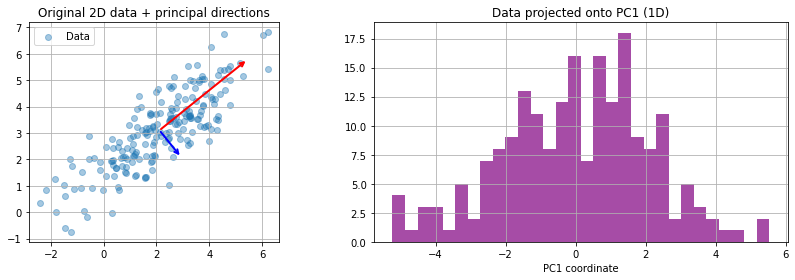

In [13]:
# PCA from scratch on 2D data
np.random.seed(0)

# Create correlated 2D data (like two features that are related)
mean = [2, 3]
cov = [[3, 2], [2, 2]]   # correlated!
X = np.random.multivariate_normal(mean, cov, 200)

# Step 1: Center
X_centered = X - X.mean(axis=0)

# Step 2: SVD (= PCA)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
principal_components = Vt  # rows = principal directions
explained_variance = (S**2) / (len(X) - 1)

print("Principal component 1 (direction of max variance):", principal_components[0])
print("Principal component 2 (perpendicular direction):", principal_components[1])
print(f"\nVariance explained: PC1={explained_variance[0]:.2f}, PC2={explained_variance[1]:.2f}")
print(f"PC1 captures {explained_variance[0]/explained_variance.sum()*100:.1f}% of total variance")

# Step 3: Project onto PC1 only (1D reduction)
X_pca_1d = X_centered @ principal_components[0]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X[:, 0], X[:, 1], alpha=0.4, label='Data')
origin = X.mean(axis=0)
for i, (pc, var) in enumerate(zip(principal_components, explained_variance)):
    ax1.annotate('', xy=origin + pc * var**0.5 * 2,
                 xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=['red','blue'][i], lw=2))
ax1.set_title('Original 2D data + principal directions')
ax1.set_aspect('equal')
ax1.grid(True)
ax1.legend()

ax2.hist(X_pca_1d, bins=30, color='purple', alpha=0.7)
ax2.set_title('Data projected onto PC1 (1D)')
ax2.set_xlabel('PC1 coordinate')
ax2.grid(True)

plt.tight_layout()
plt.show()

Data shape: (200, 2)  (n=200 samples, d=2 features)

Step 1 — Center: mean before=[2.115 3.102], after=[0. 0.]

Step 2 — Covariance matrix C:
[[2.925 2.015]
 [2.015 2.042]]
(Off-diagonal is non-zero → features are correlated)

Step 3 — Eigenvalues of C: [4.5467 0.421 ]
PC1 direction: [-0.7791 -0.6269]
PC2 direction: [ 0.6269 -0.7791]

Same eigenvalues via SVD: [4.5467 0.421 ]
PCs match (up to sign): True

Explained variance:
  PC1: 91.5%  (cumulative: 91.5%)
  PC2: 8.5%  (cumulative: 100.0%)


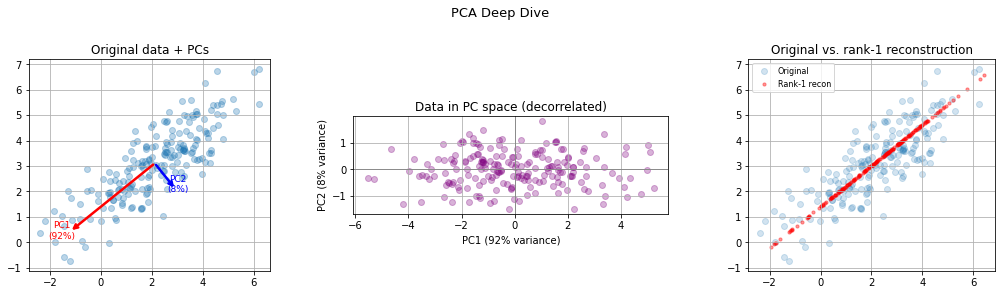


Mean reconstruction error (keep k=1 PC): 0.5218
This equals the variance captured by PC2: 0.4210 (std: 0.6489)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PCA Deep Dive — step by step from scratch
# ============================================================
np.random.seed(0)

# --- Data: 200 points, 2 correlated features (height/weight style) ---
mean = [2, 3]
cov  = [[3, 2], [2, 2]]   # off-diagonal = strong correlation
X    = np.random.multivariate_normal(mean, cov, 200)
n, d = X.shape
print(f"Data shape: {X.shape}  (n={n} samples, d={d} features)")

# ── Step 1: Center ──────────────────────────────────────────
X_c = X - X.mean(axis=0)
print(f"\nStep 1 — Center: mean before={X.mean(axis=0).round(3)}, after={X_c.mean(axis=0).round(6)}")

# ── Step 2: Covariance matrix ────────────────────────────────
C = (X_c.T @ X_c) / (n - 1)
print(f"\nStep 2 — Covariance matrix C:\n{np.round(C, 3)}")
print("(Off-diagonal is non-zero → features are correlated)")

# ── Step 3: Eigenvectors of C ────────────────────────────────
eig_vals, eig_vecs = np.linalg.eigh(C)   # eigh = symmetric matrix
# eigh returns in ascending order → reverse to get largest first
eig_vals = eig_vals[::-1]
eig_vecs = eig_vecs[:, ::-1]
print(f"\nStep 3 — Eigenvalues of C: {np.round(eig_vals, 4)}")
print(f"PC1 direction: {np.round(eig_vecs[:,0], 4)}")
print(f"PC2 direction: {np.round(eig_vecs[:,1], 4)}")

# ── Verify: same result via SVD ──────────────────────────────
_, S_svd, Vt_svd = np.linalg.svd(X_c, full_matrices=False)
eig_vals_svd = S_svd**2 / (n - 1)
print(f"\nSame eigenvalues via SVD: {np.round(eig_vals_svd, 4)}")
print(f"PCs match (up to sign): {np.allclose(np.abs(eig_vecs[:,0]), np.abs(Vt_svd[0]))}")

# ── Explained variance ───────────────────────────────────────
explained = eig_vals / eig_vals.sum()
cumulative = np.cumsum(explained)
print(f"\nExplained variance:")
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {e*100:.1f}%  (cumulative: {c*100:.1f}%)")

# ── Step 4: Project onto top-k PCs ──────────────────────────
k = 1
PC_k    = eig_vecs[:, :k]           # shape (d, k)
X_proj  = X_c @ PC_k                # shape (n, k)  ← dimensionality reduced!
X_recon = X_proj @ PC_k.T + X.mean(axis=0)  # project back to original space (for visualization)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: original data + PC arrows
ax = axes[0]
ax.scatter(X[:,0], X[:,1], alpha=0.3, label='Data')
origin = X.mean(axis=0)
colors = ['red', 'blue']
for i in range(d):
    scale = eig_vals[i]**0.5 * 2
    ax.annotate('', xy=origin + eig_vecs[:,i]*scale,
                xytext=origin,
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    ax.text(*(origin + eig_vecs[:,i]*scale*1.1), f'PC{i+1}\n({explained[i]*100:.0f}%)',
            color=colors[i], ha='center', fontsize=9)
ax.set_title('Original data + PCs')
ax.set_aspect('equal'); ax.grid(True)

# Panel 2: PC coordinates (rotated data)
ax = axes[1]
X_rotated = X_c @ eig_vecs
ax.scatter(X_rotated[:,0], X_rotated[:,1], alpha=0.3, color='purple')
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel(f'PC1 ({explained[0]*100:.0f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.0f}% variance)')
ax.set_title('Data in PC space (decorrelated)')
ax.set_aspect('equal'); ax.grid(True)

# Panel 3: reconstruction error from rank-1 approximation
ax = axes[2]
ax.scatter(X[:,0], X[:,1], alpha=0.2, label='Original')
ax.scatter(X_recon[:,0], X_recon[:,1], alpha=0.4, color='red', s=10, label='Rank-1 recon')
ax.set_title('Original vs. rank-1 reconstruction')
ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8)

plt.suptitle('PCA Deep Dive', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Reconstruction error ─────────────────────────────────────
error = np.mean(np.sum((X - X_recon)**2, axis=1)**0.5)
print(f"\nMean reconstruction error (keep k=1 PC): {error:.4f}")
print(f"This equals the variance captured by PC2: {eig_vals[1]:.4f} (std: {eig_vals[1]**0.5:.4f})")

---
## 5. Why This Matters for AI

| Technique | Where SVD/Eigenvalues Appear |
|---|---|
| **PCA** | Dimensionality reduction, data visualization, feature compression |
| **Word Embeddings (GloVe)** | Factorizes a word co-occurrence matrix via SVD |
| **LoRA** | Fine-tunes LLMs by decomposing weight updates as low-rank: $\Delta W = AB$ |
| **Attention** | $\text{softmax}(QK^T/\sqrt{d})V$ — Q,K,V are learned projections (like U,Σ,Vᵀ) |
| **Batch Normalization** | Normalizes activations — related to managing eigenvalue spread |
| **Gradient vanishing** | Caused by eigenvalues < 1 multiplied through many layers |

**Key insight:** A neural network layer $W\vec{x}$ is doing SVD decomposition implicitly:
- $V^T$ rotates the input into a better basis
- $\Sigma$ scales each direction (amplifies important ones, suppresses noise)
- $U$ rotates into the output space

---
## Exercise 2

**Questions:**
1. In the SVD of matrix A = [[1,2,3],[4,5,6],[7,8,9]], why is the last singular value ~0?
2. If you keep only k=1 singular value in the low-rank approximation, what information are you discarding?
3. In PCA: if PC1 explains 95% of variance, is it safe to discard PC2? When would it NOT be safe?
4. How does LoRA use the idea of low-rank approximation to fine-tune a large language model efficiently?

### Answers

**1. Why is the last singular value ~0?**

Matrix A = [[1,2,3],[4,5,6],[7,8,9]] has linearly dependent rows:
```
Row 3 = 2 × Row 2 − Row 1
```
Check: `2×[4,5,6] − [1,2,3] = [7,8,9]` ✅

Row 3 adds **no new information** — it is already fully described by rows 1 and 2.  
SVD detects this: rank = 2 → only 2 non-zero singular values → $S_3 \approx 0$.

---

**2. What are you discarding when k=1?**

Your approximation becomes:
$$A_1 = \sigma_1 \cdot \vec{u}_1 \vec{v}_1^T$$

This is a single **outer product** — every row of $A_1$ is a scalar multiple of the same vector $\vec{v}_1^T$.  
You keep only the **single most dominant pattern** (largest $\sigma_1$) and discard everything else:

| Discarded | What it contained |
|---|---|
| $\sigma_2 \vec{u}_2 \vec{v}_2^T$ | Secondary pattern — second most important structure |
| $\sigma_3 \vec{u}_3 \vec{v}_3^T$ ... | Fine detail, texture, noise |

In the image demo: rank-1 gives a blurry "shadow" — the coarsest shape but all edges, texture, and local variation are gone.  
In LoRA: $r=1$ means $\Delta W = \vec{b}\vec{a}^T$ can only encode **one task direction** — too restrictive for complex fine-tuning. That's why $r=8$ or $r=16$ is common in practice.

---

**3. When is it NOT safe to discard PC2?**

PC1 capturing 95% variance means PC2 has only 5% — which *sounds* small.  
It is NOT safe to discard PC2 when:

- **The task is sensitive to that 5%** — e.g., in medical diagnosis, PC2 might capture a rare but critical disease signal that is orthogonal to the dominant healthy-population variation
- **PC2 carries class-discriminative information** — two classes may have identical PC1 projections but differ on PC2 (think: two clusters aligned along the minor axis)
- **Downstream model is non-linear** — a neural network may amplify small variance directions into large output differences
- **Outlier detection** — anomalies often live in the low-variance directions (they break the dominant pattern, not add to it)

**Rule of thumb:** "% variance explained" measures how much the data *varies* in that direction, not how *useful* that direction is for your task.

---

**4. How does LoRA use low-rank approximation?**

Full fine-tuning updates every weight: $W \leftarrow W + \Delta W$ where $\Delta W \in \mathbb{R}^{d \times d}$ — storing $d^2$ new parameters per layer.

LoRA's insight: **$\Delta W$ is empirically low-rank** during fine-tuning. So instead:

$$\Delta W = B \cdot A \quad \text{where } B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times d},\; r \ll d$$

- **Freeze** $W$ (never updated)  
- **Train only** $A$ and $B$: $2dr$ parameters instead of $d^2$
- **Forward pass:** `output = W @ x + B @ (A @ x)` — no extra latency at inference after merging

Result: For LLaMA-7B with $r=8$, parameter count drops **256×** per weight matrix — enabling fine-tuning on a single GPU in hours instead of needing a cluster for days.

---
## Summary

| Concept | Formula | AI Usage |
|---|---|---|
| Eigendecomposition | $A\vec{v} = \lambda\vec{v}$ | PCA, stability analysis |
| SVD | $A = U\Sigma V^T$ | Compression, embeddings, LoRA |
| Low-rank approx | $A \approx U_k\Sigma_k V_k^T$ | Model pruning, LoRA, image compression |
| PCA | SVD on centered X | Visualization, feature reduction |

---
## Next: Day 3 — Matrix Operations in NumPy
Broadcasting, batch matrix operations, , and the NumPy patterns used in every AI framework.

---
## My Notes
> *(Write your own observations, questions, and breakthroughs here)*